# 1. Analysis and Product Recommendation for Men's Shirts Using Web Scraping and Data Analysis from Zalora



=================================================

This project aims to collect and analyze men's shirt product data from the Zalora e-commerce platform using web scraping techniques. 
The collected data is then processed through data cleaning, exploratory data analysis (EDA), and filtering based on defined criteria to generate the best product recommendations suited to user needs.

=================================================

# 2. Problem Statement

**Problem:**
- I need several new shirts for various events in the coming week, but I have a limited budget.

**Analysis Goal:**
- Identify men's shirt products that offer the best combination of affordable price, product popularity, and high customer rating.

**Selection Criteria:**
- Product is labeled as "Most Popular"
- Product price is below IDR 500,000
- Product has a high customer rating

# 3. Technical Workflow

Several technologies are used in this project to support the data processing pipeline:

- **Selenium** is used for browser automation during the web scraping process.
- **BeautifulSoup** is used for HTML parsing and extracting product information.
- **Pandas** is used for data cleaning, transformation, and analysis.
- **Matplotlib** and **Seaborn** are used for data visualization in the EDA stage.
- **SQLAlchemy** is used to store the resulting data into a SQLite database.


## 3.1 Install Library


In [1]:
# Install Selenium for browser automation and BeautifulSoup for HTML parsing
!pip install bs4 selenium


In [2]:
# Install Pandas for data manipulation
!pip install pandas

In [3]:
# Instalasi matplitlib dan seaborn for data visualization
!pip install matplotlib
!pip install seaborn

## 3.2 Import Library

In [4]:
# Import Pandas for dataframe manipulation
import pandas as pd
# Import BeautifulSoup for HTML parsing
from bs4 import BeautifulSoup
# Import Selenium for browser automation
from selenium import webdriver
# Import Requests for HTTP requests to the target website
import requests
# Import time for adding delays between page loads
import time

import re

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Validate site access. A response of 200 (OK) means the site can be scraped.
requests.get('https://www.zalora.co.id/c/men/pakaian/sale/c-26?vc_applicable=true&categoryId=31&page=1')

<Response [200]>

In [6]:
# Open automated browser
driver =  webdriver.Chrome()


In [7]:
# Close automated browser
driver.close()

## 3.3 Data Collecting

Web Scraping Implementation on Zalora.co.id

In [8]:
# Initialize the webdriver
driver = webdriver.Chrome()

# Initialize empty lists to store scraped data (5 columns)
product_name = []
product_price = []
store_name = []
product_rating = []
trending = []

# Scrape up to page 10
for page in range(1, 11):
    # Navigate to the target page
    web_link = f'https://www.zalora.co.id/c/men/pakaian/sale/c-26?vc_applicable=true&categoryId=31&page={page}'
    driver.get(web_link)
    # Wait 1 second for the page to load
    time.sleep(1)
    # Get page source HTML
    html = driver.page_source
    # Parse HTML with BeautifulSoup
    soup = BeautifulSoup(html, 'html.parser')
    # Find all product card containers
    product_cards = soup.find_all('div', {'class': 'flex flex-col min-h-[358px] tablet:min-h-[380px] desktop:min-h-[500px]'})

    # Extract data from each product card
    for data in product_cards:
        try:
            # Scrape product name
            print(data.find('h3', {'data-test-id': 'productTitle'}))
            product_name.append(data.find('h3', {'data-test-id': 'productTitle'}).get_text())
        except:
            # If not found, append None
            print(None)
            product_name.append(None)
        try:
            # Scrape product price
            print(data.find('div', {'data-test-id': 'originalPrice'}))
            product_price.append(data.find('div', {'data-test-id': 'originalPrice'}).get_text())
        except:
            print(None)
            product_price.append(None)
        try:
            # Scrape store/brand name
            print(data.find('h3', {'data-test-id': 'productBrandName'}))
            store_name.append(data.find('h3', {'data-test-id': 'productBrandName'}).get_text())
        except:
            print(None)
            store_name.append(None)
        try:
            # Scrape product rating
            print(data.find('span', {'class': 'text-xxs font-medium leading-3 text-grey-60'}))
            product_rating.append(data.find('span', {'class': 'text-xxs font-medium leading-3 text-grey-60'}).get_text())
        except:
            print(None)
            product_rating.append(None)
        try:
            # Scrape trending/most popular label
            print(data.find('span', {'class': 'text-[#34669F]'}))
            trending.append(data.find('span', {'class': 'text-[#34669F]'}).get_text())
        except:
            print(None)
            trending.append(None)


<h3 class="overflow-hidden text-ellipsis whitespace-nowrap text-sm" data-test-id="productTitle">Gloaming Kemeja Flanel Veterano Unisex Luserra</h3>
<div class="max-w-full truncate text-grey-60 line-through tablet:text-xs text-xxs tablet:text-xs" data-test-id="originalPrice">Rp 320.000</div>
<h3 class="shrink-[10] truncate text-base font-bold" data-test-id="productBrandName" title="Gloaming">Gloaming</h3>
<span class="text-xxs font-medium leading-3 text-grey-60" data-test-id="rating">5.0</span>
None
None
<h3 class="overflow-hidden text-ellipsis whitespace-nowrap text-sm" data-test-id="productTitle">Vigge Shirts</h3>
<div class="max-w-full truncate text-grey-60 line-through tablet:text-xs text-xxs tablet:text-xs" data-test-id="originalPrice">Rp 469.900</div>
<h3 class="shrink-[10] truncate text-base font-bold" data-test-id="productBrandName" title="X-EIGHT">X-EIGHT</h3>
<span class="text-xxs font-medium leading-3 text-grey-60" data-test-id="rating">4.9</span>
None
None
<h3 class="overflo

Load Scraped Data into a DataFrame

In [39]:
# Create a DataFrame and load scraped data into each column
df = pd.DataFrame()
df['Product Name'] = product_name
df['Price'] = product_price
df['Store'] = store_name
df['Rating'] = product_rating
df['Paling Populer'] = trending


In [40]:
# Display the raw scraped data
df

,Product Name,Price,Store,Rating,Paling Populer
0,Gloaming Kemeja Flanel Veterano Unisex Luserra,Rp 320.000,Gloaming,5.0,None
1,Vigge Shirts,Rp 469.900,X-EIGHT,4.9,None
2,Gloaming Kemeja Flanel Boxy Oversize Pendek Ri...,Rp 210.000,Gloaming,4.4,None
3,AMK Kemeja Pria Lengan Pendek SHP Diego S/S Olive,Rp 449.000,AMK,5.0,None
4,Jobb Bellagio Kemeja Pria Lengan Panjang Slim ...,Rp 629.000,Jobb,4.8,Paling Populer
...,...,...,...,...,...
385,AMK CIPTA BLACK,Rp 449.000,AMK,5.0,None
386,Black Regular Fit Oversized Collar 100% Viscos...,Rp 459.000,Trendyol,None,None
387,Arion Printing Shirt LS,Rp 359.000,VENGOZ,4.9,None
388,Garcia Shirt Camel Brown LS,Rp 399.000,VENGOZ,4.9,None


## 3.4 Data Cleaning

Raw scraped data often contains unnecessary characters (such as currency symbols or extra text). 
This stage aims to clean the data so it is ready for numerical analysis.


In [41]:
# Show the first 5 row
df.head()

,Product Name,Price,Store,Rating,Paling Populer
0,Gloaming Kemeja Flanel Veterano Unisex Luserra,Rp 320.000,Gloaming,5.0,None
1,Vigge Shirts,Rp 469.900,X-EIGHT,4.9,None
2,Gloaming Kemeja Flanel Boxy Oversize Pendek Ri...,Rp 210.000,Gloaming,4.4,None
3,AMK Kemeja Pria Lengan Pendek SHP Diego S/S Olive,Rp 449.000,AMK,5.0,None
4,Jobb Bellagio Kemeja Pria Lengan Panjang Slim ...,Rp 629.000,Jobb,4.8,Paling Populer


In [42]:
# Check the number of missing values per column
df.isnull().sum()

Product Name        0
Price              78
Store               0
Rating             48
Paling Populer    313
dtype: int64

In [43]:
# Check data structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Product Name    390 non-null    object
 1   Price           312 non-null    object
 2   Store           390 non-null    object
 3   Rating          342 non-null    object
 4   Paling Populer  77 non-null     object
dtypes: object(5)
memory usage: 15.4+ KB


In [45]:
# Check for duplicate rows
df.duplicated().sum()

12

The data structure check reveals several issues: missing values, duplicate rows, and incorrect data types for the 'Price' and 'Rating' columns, both need to be converted to numeric format.


In [46]:
# Fill missing values in 'Rating' with 0
df.loc[df['Rating'].isna(), 'Rating'] = 0

# Convert 'Paling Populer' column to binary: 1 if labeled, 0 if None
df["Paling Populer"] = df["Paling Populer"].apply(lambda x: 1 if pd.notna(x) else 0)

In [47]:
# Remove 'Rp' and '.' from 'Price' to enable numeric conversion
df['Price'] = df['Price'].str.replace('Rp', '', regex=False).str.replace('.', '', regex=False)

# Remove misisng values in 'Price
df = df.dropna(subset=['Price'])

In [48]:
# Remove Data Duplicates
df = df.drop_duplicates()

In [51]:
# Convert 'Price' to integer type
df['Price'] = df['Price'].astype(int)
# Convert 'Rating' to float type
df['Rating'] = df['Rating'].astype(float)

Cleaning has been completed. Lets verify the results

In [52]:
# Display the first 5 rows.
df.head() 

,Product Name,Price,Store,Rating,Paling Populer
0,Gloaming Kemeja Flanel Veterano Unisex Luserra,320000,Gloaming,5.0,0
1,Vigge Shirts,469900,X-EIGHT,4.9,0
2,Gloaming Kemeja Flanel Boxy Oversize Pendek Ri...,210000,Gloaming,4.4,0
3,AMK Kemeja Pria Lengan Pendek SHP Diego S/S Olive,449000,AMK,5.0,0
4,Jobb Bellagio Kemeja Pria Lengan Panjang Slim ...,629000,Jobb,4.8,1


In [53]:
# Verify missing values
df.isnull().sum()


Product Name      0
Price             0
Store             0
Rating            0
Paling Populer    0
dtype: int64

In [54]:
# Verify data structure
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 304 entries, 0 to 389
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Name    304 non-null    object 
 1   Price           304 non-null    int32  
 2   Store           304 non-null    object 
 3   Rating          304 non-null    float64
 4   Paling Populer  304 non-null    int64  
dtypes: float64(1), int32(1), int64(1), object(2)
memory usage: 13.1+ KB


**Data cleaning completed successfully:**
1. The 'Paling Populer' column has been converted to binary values: **1** (Most Popular) and **0** (Regular).
2. Missing values in 'Rating' have been replaced with **0**.
3. Currency symbol 'Rp' and thousand separators have been removed from 'Price'.
4. 'Price' has been converted to **int** and 'Product Rating' to **float**.
5. Duplicate rows have been removed.


In [55]:
# Display the cleaned DataFrame
df



,Product Name,Price,Store,Rating,Paling Populer
0,Gloaming Kemeja Flanel Veterano Unisex Luserra,320000,Gloaming,5.0,0
1,Vigge Shirts,469900,X-EIGHT,4.9,0
2,Gloaming Kemeja Flanel Boxy Oversize Pendek Ri...,210000,Gloaming,4.4,0
3,AMK Kemeja Pria Lengan Pendek SHP Diego S/S Olive,449000,AMK,5.0,0
4,Jobb Bellagio Kemeja Pria Lengan Panjang Slim ...,629000,Jobb,4.8,1
...,...,...,...,...,...
385,AMK CIPTA BLACK,449000,AMK,5.0,0
386,Black Regular Fit Oversized Collar 100% Viscos...,459000,Trendyol,0.0,0
387,Arion Printing Shirt LS,359000,VENGOZ,4.9,0
388,Garcia Shirt Camel Brown LS,399000,VENGOZ,4.9,0


## 3.5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) aims to understand the characteristics of the dataset collected through web scraping. 
In this stage, statistical analysis and data visualization are performed to identify patterns, data distributions, and relationships between variables.

### 3.5.0. Descriptive Statistics

Before visualization, descriptive statistics are examined to get an initial overview of the distribution and characteristics of the data.


In [56]:
# Descriptive statistics for all numeric columns
df.describe()


,Price,Rating,Paling Populer
count,3.040000e+02,304.000000,304.000000
mean,4.691816e+05,4.184539,0.180921
std,1.661669e+05,1.652259,0.385587
min,1.599000e+05,0.000000,0.000000
25%,3.990000e+05,4.700000,0.000000
50%,4.490000e+05,4.850000,0.000000
75%,4.999000e+05,5.000000,0.000000
max,1.359000e+06,5.000000,1.000000


### 3.5.1. Price Distribution

Price distribution analysis is conducted to understand the spread of product prices available in the dataset. 
By examining the distribution, we can identify the most common price range and detect products with unusually low or high prices compared to others.

The distribution is visualized using a histogram to show product frequency across each price range.


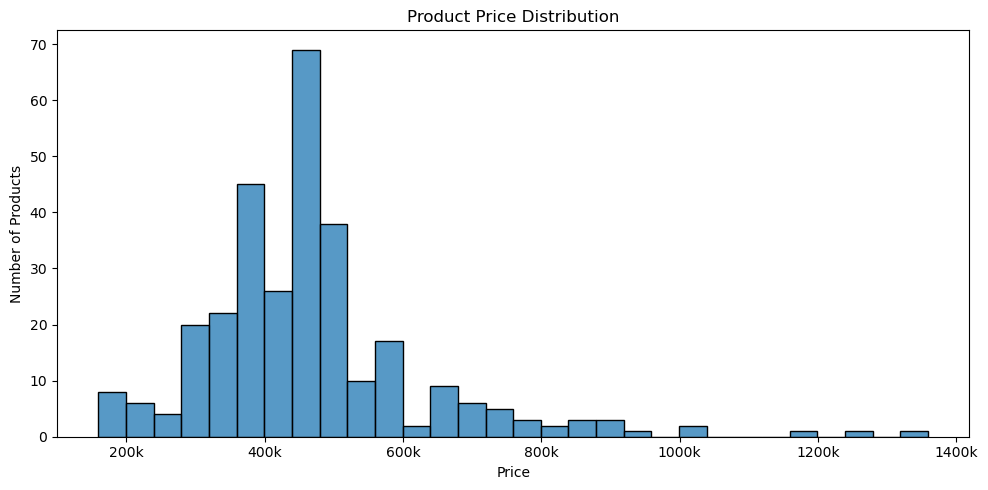

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 5))
sns.histplot(df["Price"], bins=30)
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))
plt.tight_layout()
plt.show()


**Key Insights:**

- Based on the price distribution visualization, most shirts are priced between IDR 250,000 and IDR 500,000. 
This indicates that the men's shirt category on Zalora is dominated by mid-range products that are relatively affordable for consumers.

- There are a few products priced above IDR 1,000,000 that can be categorized as premium products, but their quantity is relatively small compared to mid-range products.


### 3.5.2. Top Brands by Product Count

This analysis aims to identify which brands or stores have the highest number of products in the dataset. 
This provides an overview of which brands are most active or dominant in the analyzed product category.


In [58]:
df["Store"].value_counts().head(10)

Store
AMK             46
Police Denim    24
Platini         21
Trendyol        20
Gloaming        17
WOOD            14
Bombboogie      12
Hush Puppies    11
MOC             11
Jobb            10
Name: count, dtype: int64

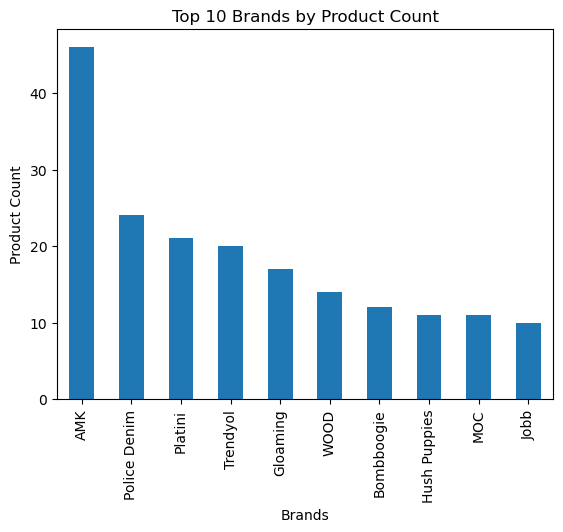

In [59]:
df["Store"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Brands by Product Count")
plt.xlabel("Brands")
plt.ylabel("Product Count")
plt.show()

**Insights:**

- AMK has the highest product count by a significant margin, contributing nearly twice as many products as the second-ranked brand. This indicates a strong market presence or aggressive product expansion strategy.

- The chart shows a clear gap between AMK and the remaining brands, suggesting that the market is highly concentrated among a few major players.

- Brands such as Police Denim, Platini, and Trendyol maintain relatively strong product counts, indicating healthy competition in the mid-market segment.

- Brands like Bombboogie, Hush Puppies, MOC, and Jobb have smaller portfolios but still contribute consistently to the market diversity.

- Potential dependence on a single dominant brand
The heavy reliance on AMK may create business risk if customer demand shifts or if the brand underperforms in the future.


**Business Recommendation:**

- Diversify the product portfolio to reduce dependency on the dominant brand.
- Strengthen partnerships and promotions for mid-tier brands to improve competitive balance.
- Analyze why AMK performs strongly (pricing, quality, variety, or popularity) and apply similar strategies to other brands.
- Explore growth opportunities for smaller brands through targeted marketing or product expansion initiatives.

### 3.5.3 Rating Distribution

Product rating distribution is analyzed to understand customer satisfaction levels for available products. 
Product rating can be an important indicator for assessing product quality.


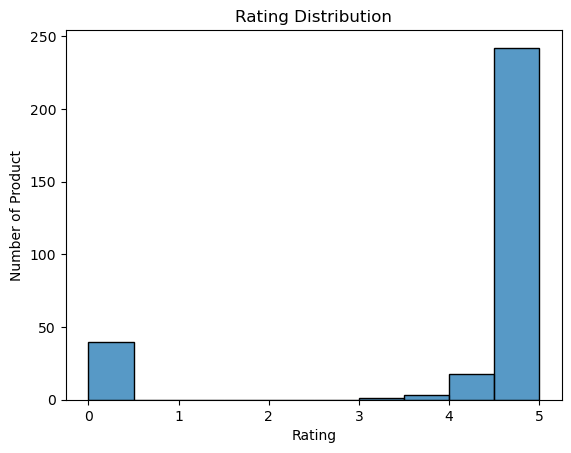

In [60]:
sns.histplot(df["Rating"], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Product")
plt.show()

**Insights:**

- Most products receive very high ratings, indicating overall strong customer satisfaction and positive user experience.
- Ratings below 4.0 appear only in small numbers, suggesting that the majority of products perform well in terms of customer perception.

- There is a noticeable spike at rating 0, which may indicate that products without reviews or inactive/new listings.


**Business Recommendation:**

- Maintain quality standards for high-rated products to preserve customer satisfaction.
- Encourage more balanced customer feedback collection to reduce possible rating bias and gain deeper insights into product performance.

### 3.5.4. Relationship Between Price and Product Rating

This analysis aims to examine whether there is a relationship between product price and customer rating. 
The visualization is done using a scatter plot.


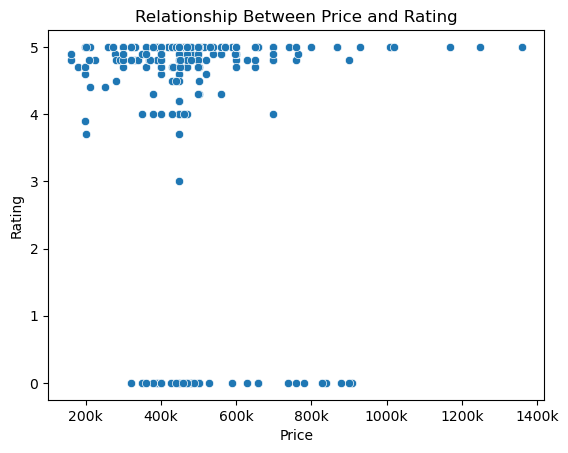

In [62]:
sns.scatterplot(x="Price", y="Rating", data=df)
plt.title("Relationship Between Price and Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))
plt.show()

**Insight:**

- Higher prices do not necessarily lead to higher ratings
Both lower-priced and premium-priced properties tend to have similar ratings (around 4.5–5.0). This suggests that increasing price does not significantly improve customer ratings.

- Rating variation is higher in the mid-price segment
Properties priced around 300k–600k show ratings ranging from 3 to 5, while higher-priced properties tend to maintain consistently high ratings.

**Business Recommendation:**

- Focus on the mid-price segment, as it combines high demand with strong customer satisfaction.
- Investigate listings with a rating of 0 to improve data quality and analysis accuracy.
- Do not rely solely on higher pricing to improve perceived quality; customer experience appears to have a stronger impact on ratings than price alone.

### 3.5.5. Most Popular Product Analysis

This analysis is conducted to determine how many products carry the 'Paling Populer' label compared to regular products.


In [63]:
df["Paling Populer"].value_counts()

Paling Populer
0    249
1     55
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_14416\3041303107.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Regular (0)', 'Most Popular (1)'])


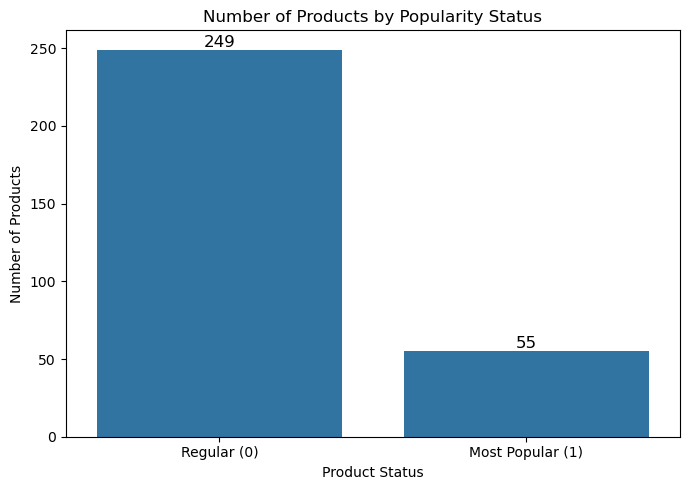

In [64]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="Paling Populer", data=df)
ax.set_xticklabels(['Regular (0)', 'Most Popular (1)'])
plt.title("Number of Products by Popularity Status")
plt.xlabel("Product Status")
plt.ylabel("Number of Products")

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:**

- The majority of products (249) fall under the “Regular” category, while only 55 products are labeled as “Most Popular.” This indicates that only a small portion of the catalog achieves high popularity status.
- Although “Most Popular” products account for a smaller share, they are likely the main drivers of customer attention, engagement, and possibly sales performance.


**Recommendation Business:**
- Analyze the characteristics of “Most Popular” products (price, brand, ratings, category, promotions) to replicate their success across other products.
- Increase marketing exposure for regular products through campaigns, recommendations, or discounts.
- Monitor dependency on popular products to reduce business risk and maintain balanced portfolio performance.
- Use customer feedback and performance analytics to identify which regular products have the highest potential to become popular.

### 3.5.6. Brands with the Highest Proportion of 'Most Popular' Products

This analysis aims to identify which brands have the highest proportion of products labeled 'Most Popular'.


In [65]:
df.groupby("Store")["Paling Populer"].mean().sort_values(ascending=False).head(10)

Store
Arnold Palmer    1.000000
Volcom           1.000000
Edwin Jeans      1.000000
Executive        1.000000
Giordano         0.800000
WOOD             0.714286
Lois Jeans       0.666667
Hush Puppies     0.636364
RBJ              0.500000
Insight          0.500000
Name: Paling Populer, dtype: float64

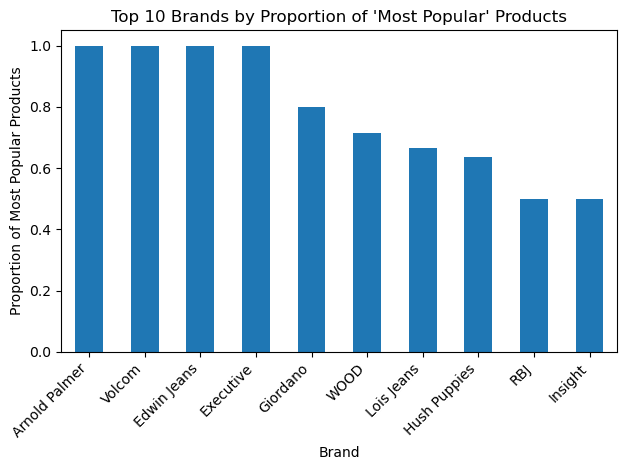

In [66]:
df.groupby("Store")["Paling Populer"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Brands by Proportion of 'Most Popular' Products")
plt.xlabel("Brand")
plt.ylabel("Proportion of Most Popular Products")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:**

- Brands such as Arnold Palmer, Volcom, Edwin Jeans, and Executive show a 100% proportion of “Most Popular” products, indicating exceptionally strong product performance and customer appeal within their portfolios.
- Some brands may not have the largest number of products, but they maintain a very high proportion of popular items. This suggests that product relevance and customer preference are more important than portfolio size alone.
- With popularity proportions around 70–80%, Giordano and WOOD also consistently produce products that resonate well with customers.
- Hush Puppies, RBJ, and Insight still maintain a reasonable proportion of popular products but may have opportunities to improve competitiveness or customer engagement.
- The differences in proportions suggest that factors such as brand reputation, pricing strategy, product quality, and marketing effectiveness strongly influence product popularity.

**Recommendation Business:**
- Study the strategies used by top-performing brands (e.g., product design, pricing, promotions, customer targeting) and apply similar approaches to lower-performing brands.
- Prioritize marketing investment in brands with consistently high popularity ratios to maximize return on investment.
- Improve underperforming brands through better product positioning, enhanced promotions, or customer feedback analysis.
- Combine popularity analysis with sales and profitability metrics to identify the most valuable brands for long-term growth.

### 3.5.7. EDA Summary

The exploratory data analysis reveals several important patterns regarding product ratings, pricing, brand performance, and popularity status.

Overall, the EDA indicates that:

- Customer satisfaction is generally high.
- Mid-priced products dominate the market.
- Product popularity is concentrated among selected brands and products.
- Brand effectiveness is driven more by product performance than by product quantity.

## 3.6. Product Filtering Based on Criteria


To obtain product recommendations that match the user's needs, the dataset is filtered based on the following pre-defined criteria.

**Filtering Criteria:**
- Product is labeled as "Paling Populer"
- Product price is below IDR 500,000
- Product has a customer rating (rating > 0)


In [67]:
recommendations = df[
    (df["Price"] < 500000) &
    (df["Paling Populer"] == 1) &
    (df["Rating"] > 0) # Only products with a valid rating
]

print(f"Number of products meeting all criteria: {len(recommendations)} products")
recommendations.sort_values(by="Rating", ascending=False).head(10)


Number of products meeting all criteria: 37 products


,Product Name,Price,Store,Rating,Paling Populer
103,Kemeja Regular Pria Vertiline,419900,Bombboogie,5.0,1
339,Short Sleeve Textured Shirt,329900,Executive,5.0,1
115,AMK Kemeja Polos Oversize Pria Lengan Panjang ...,469000,AMK,5.0,1
99,Short Sleeve Textured Stretch Shirt,329900,Executive,5.0,1
95,Relaxed Fit Short Sleeve Shirt,399900,WOOD,5.0,1
286,Long Sleeve Oxford Shirt,429900,WOOD,5.0,1
224,Short Sleeve Checks Shirt with Pocket,399900,WOOD,5.0,1
328,Regular Fit Short Sleeve Twill Shirt,399900,WOOD,5.0,1
51,Gloaming ⁠Kemeja Flanel Boxy Oversize Pendek C...,210000,Gloaming,5.0,1
370,AMK Kemeja Batik Pria Lengan Panjang SHB Banja...,469000,AMK,5.0,1


Based on the filtering results, several products successfully meet all three defined criteria. 
These products can be considered **best value** options as they offer an affordable price, carry the 'Most Popular' label, and have a high customer rating.

This finding demonstrates that consumers can still find high-quality products within a limited budget, as long as the selection process is carried out selectively using available data.


## 3.7. Analysis Limitations

Several limitations to consider when interpreting the results of this analysis:

1. **Limited Data Coverage** — Data was only collected from the first 10 pages of the men's shirt sale category on Zalora, and therefore does not represent the full product catalog.
2. **Dynamic Data** — Prices, ratings, and 'Most Popular' labels can change at any time. The analysis results are only relevant at the time of data collection.
3. **Rating Unavailability** — Products without customer reviews have no rating and therefore cannot be included in rating-based filtering.
4. **HTML Structure Dependency** — The scraping script relies on Zalora's HTML class names and attributes, which can change at any time and may require the script to be updated accordingly.


# 4. Conclusion

- Based on the data analysis conducted on men's shirt products from the Zalora platform, web scraping successfully collected product information such as product name, price, brand name, customer rating, and popularity status.

- After data cleaning, the dataset was analyzed using exploratory data analysis (EDA) to understand data characteristics, including price distribution, customer rating distribution, and product popularity across brands.

- The analysis shows that the market is dominated by highly rated products, especially within the mid-price segment, indicating strong overall customer satisfaction regardless of pricing level. Higher prices do not necessarily guarantee better ratings, suggesting that customer experience and product quality are more influential than price alone.

- A filtering process was then applied based on the defined criteria: products labeled 'Most Popular', priced below IDR 500,000, and having a valid customer rating. The filtering produced several products that can be recommended as the best choices as they meet all criteria.

- Overall, this project demonstrates how data collection through web scraping, data processing, exploratory data analysis, and filtering can be used to support data-driven decision making in selecting the most suitable products based on user needs.


# 5. Data Storage

## 5.1 Export DataFrame to CSV

In [68]:
# Export cleaned DataFrame to CSV
df.to_csv('Zalora_DataFrame_Cleaned.csv')


In [69]:
# Export filtered recommendations to CSV
recommendations.to_csv('Zalora_DataFrame_Recommendation.csv')


## 5.2 Export to SQL

To ensure data integrity and scalability, the final results are stored in a relational database format (SQLite) for easy integration with other systems in the future.


### 5.2.1 Install sqalchemy

In [70]:
!pip install sqlalchemy

### 5.2.2 Export DataFrame to Database Format (.db and .sql)

In [ ]:
from sqlalchemy import create_engine
import sqlite3

# Create a SQLite engine
engine1 = create_engine("sqlite:///cleaned.db")
engine2 = create_engine("sqlite:///recommendation.db")

# Save the DataFrame to a table in the SQLite database
df.to_sql("cleaned", engine1, if_exists="replace", index=False)
recommendations.to_sql("recommendation", engine2, if_exists="replace", index=False)

# Export database to a .sql file
conn = sqlite3.connect("cleaned.db")
with open("DataFrame Zalora Cleaned.sql", "w") as f:
    for line in engine1.raw_connection().iterdump():
        f.write(f"{line}\n")
        
conn = sqlite3.connect("recommendation.db")
with open("DataFrame Zalora Recommendation.sql", "w") as f:
    for line in engine2.raw_connection().iterdump():
        f.write(f"{line}\n")
